In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

PROJECT_ROOT = os.path.abspath("..")

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "final_security.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "model_comparison"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)

Project root: /Users/mustafaahmed/Documents/Security Code Review Analysis
Dataset: /Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/final_security.csv
Output directory: /Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/model_comparison


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (9230, 13)


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,security_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [3]:
print("Original label distribution:")
display(df["security_label"].value_counts().sort_index())

binary_df = df[
    df["security_label"].isin([0, 1])
].copy()

binary_df["text"] = (
    binary_df["comment"]
    .fillna("")
    .astype(str)
    .str.strip()
)

binary_df = binary_df[
    binary_df["text"] != ""
].copy()

X = binary_df["text"]
y = binary_df["security_label"].astype(int)

print("Binary dataset shape:", binary_df.shape)

print("\nBinary label distribution:")
display(y.value_counts().sort_index())

Original label distribution:


security_label
0    6119
1    3028
2      83
Name: count, dtype: int64

Binary dataset shape: (9147, 14)

Binary label distribution:


security_label
0    6119
1    3028
Name: count, dtype: int64

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting distribution:")
display(y_test.value_counts().sort_index())

Training samples: 7317
Testing samples: 1830

Training distribution:


security_label
0    4895
1    2422
Name: count, dtype: int64


Testing distribution:


security_label
0    1224
1     606
Name: count, dtype: int64

In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Training TF-IDF shape: (7317, 14862)
Testing TF-IDF shape: (1830, 14862)
Vocabulary size: 14862


In [6]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)


random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


models = {
    "Logistic Regression": logistic_model,
    "Linear SVM": svm_model,
    "Random Forest": random_forest_model
}

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Linear SVM
- Random Forest


In [7]:
results = []
predictions = {}
training_times = {}

for name, model in models.items():

    print("=" * 60)
    print("Training:", name)

    start_time = time.time()

    model.fit(
        X_train_tfidf,
        y_train
    )

    training_time = time.time() - start_time

    start_prediction_time = time.time()

    y_pred = model.predict(
        X_test_tfidf
    )

    prediction_time = time.time() - start_prediction_time

    predictions[name] = y_pred
    training_times[name] = training_time

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    results.append({
        "model": name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "training_time_seconds": training_time,
        "prediction_time_seconds": prediction_time
    })

    print("Training time:", round(training_time, 2), "seconds")
    print("Prediction time:", round(prediction_time, 2), "seconds")
    print("Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1:", round(f1, 4))

Training: Logistic Regression
Training time: 0.03 seconds
Prediction time: 0.0 seconds
Accuracy: 0.9705
Balanced Accuracy: 0.9563
Precision: 0.9964
Recall: 0.9142
F1: 0.9535
Training: Linear SVM
Training time: 0.01 seconds
Prediction time: 0.0 seconds
Accuracy: 0.976
Balanced Accuracy: 0.9649
Precision: 0.9947
Recall: 0.9323
F1: 0.9625
Training: Random Forest
Training time: 0.82 seconds
Prediction time: 0.04 seconds
Accuracy: 0.9683
Balanced Accuracy: 0.9526
Precision: 0.9982
Recall: 0.9059
F1: 0.9498


In [8]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "f1_score",
    ascending=False
).reset_index(drop=True)

comparison_table = results_df.copy()

display(results_df)

,model,accuracy,balanced_accuracy,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives,training_time_seconds,prediction_time_seconds
0,Linear SVM,0.975956,0.964946,0.994718,0.932343,0.962521,1221,3,41,565,0.013302,0.000155
1,Logistic Regression,0.970492,0.956279,0.996403,0.914191,0.953528,1222,2,52,554,0.031801,0.000184
2,Random Forest,0.968306,0.952562,0.998182,0.905941,0.949827,1223,1,57,549,0.816287,0.038108


In [9]:
percentage_table = comparison_table.copy()

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1_score"
]

for column in metric_columns:
    percentage_table[column] = (
        percentage_table[column] * 100
    ).round(2).astype(str) + "%"

display(percentage_table)

,model,accuracy,balanced_accuracy,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives,training_time_seconds,prediction_time_seconds
0,Linear SVM,97.6%,96.49%,99.47%,93.23%,96.25%,1221,3,41,565,0.013302,0.000155
1,Logistic Regression,97.05%,95.63%,99.64%,91.42%,95.35%,1222,2,52,554,0.031801,0.000184
2,Random Forest,96.83%,95.26%,99.82%,90.59%,94.98%,1223,1,57,549,0.816287,0.038108


In [10]:
results_path = os.path.join(
    OUTPUT_DIR,
    "model_comparison_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("Results saved to:")
print(results_path)

Results saved to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/model_comparison/model_comparison_results.csv


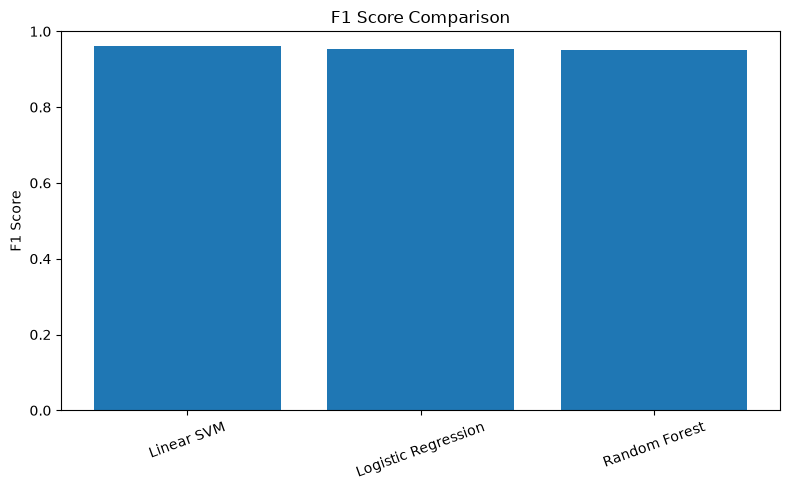

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    comparison_table["model"],
    comparison_table["f1_score"]
)

ax.set_title("F1 Score Comparison")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

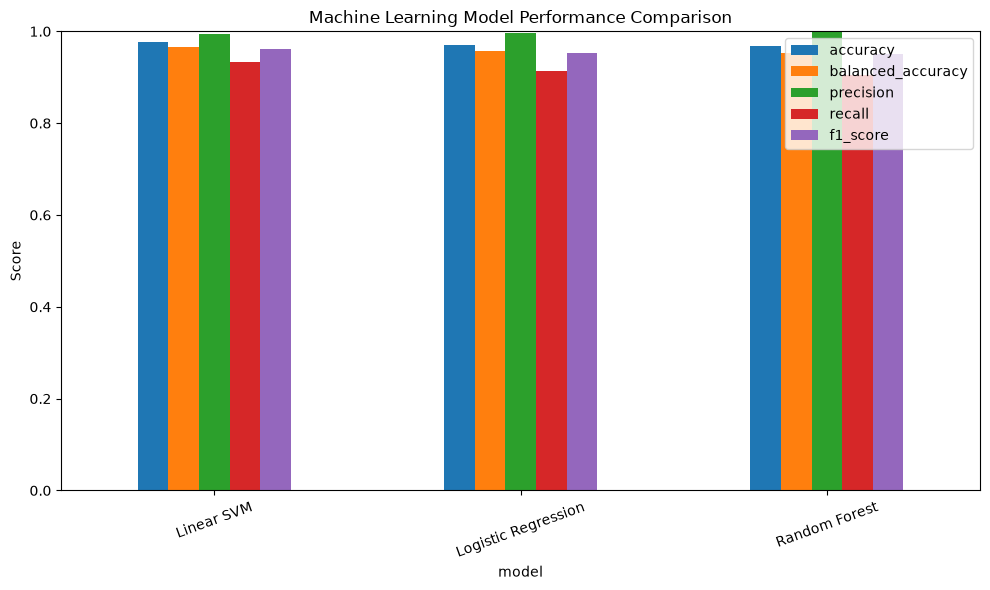

In [12]:
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1_score"
]

plot_data = comparison_table.set_index("model")[
    metrics_to_plot
]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Machine Learning Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

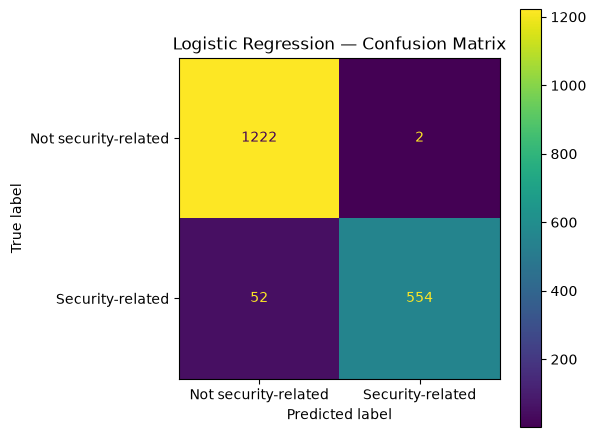

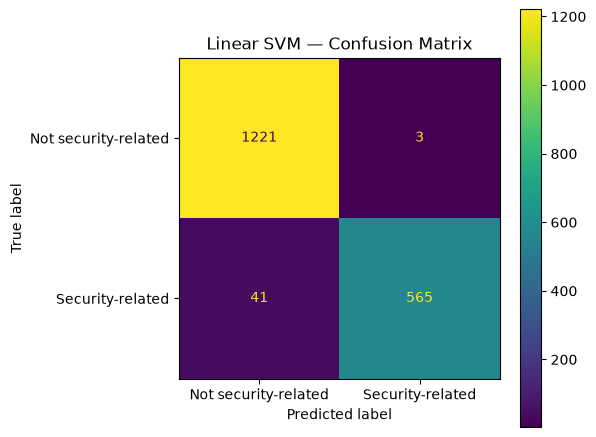

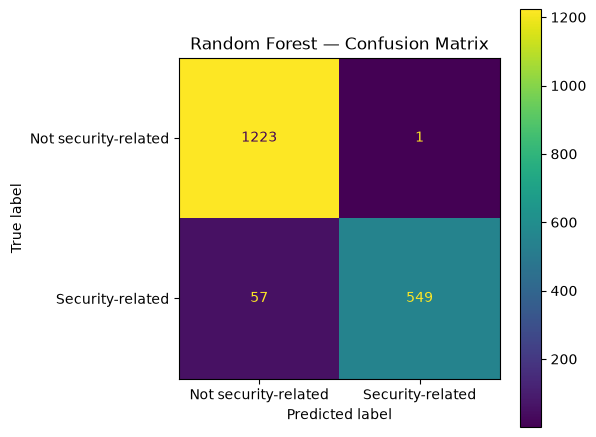

In [13]:
for name in models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Not security-related",
            "Security-related"
        ]
    ).plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"{name} — Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

In [14]:
for name in models:

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                "Not security-related",
                "Security-related"
            ],
            zero_division=0
        )
    )

Logistic Regression
                      precision    recall  f1-score   support

Not security-related       0.96      1.00      0.98      1224
    Security-related       1.00      0.91      0.95       606

            accuracy                           0.97      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.97      0.97      0.97      1830

Linear SVM
                      precision    recall  f1-score   support

Not security-related       0.97      1.00      0.98      1224
    Security-related       0.99      0.93      0.96       606

            accuracy                           0.98      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.98      0.98      0.98      1830

Random Forest
                      precision    recall  f1-score   support

Not security-related       0.96      1.00      0.98      1224
    Security-related       1.00      0.91      0.95       606

            accur

In [15]:
error_comparison = results_df[
    [
        "model",
        "true_negatives",
        "false_positives",
        "false_negatives",
        "true_positives"
    ]
].copy()

display(error_comparison)

,model,true_negatives,false_positives,false_negatives,true_positives
0,Linear SVM,1221,3,41,565
1,Logistic Regression,1222,2,52,554
2,Random Forest,1223,1,57,549


In [16]:
prediction_df = binary_df.loc[
    X_test.index
].copy()

prediction_df["actual_label"] = y_test.values

for name, y_pred in predictions.items():

    safe_name = (
        name
        .lower()
        .replace(" ", "_")
    )

    prediction_df[
        f"{safe_name}_prediction"
    ] = y_pred

prediction_path = os.path.join(
    OUTPUT_DIR,
    "model_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print("Predictions saved to:")
print(prediction_path)

Predictions saved to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/model_comparison/model_predictions.csv


In [17]:
prediction_columns = [
    "logistic_regression_prediction",
    "linear_svm_prediction",
    "random_forest_prediction"
]

prediction_df["prediction_variants"] = (
    prediction_df[prediction_columns]
    .nunique(axis=1)
)

disagreements = prediction_df[
    prediction_df["prediction_variants"] > 1
].copy()

print(
    "Number of comments where models disagree:",
    len(disagreements)
)

display(disagreements.head(30))

Number of comments where models disagree: 24


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,security_label,review_notes,text,actual_label,logistic_regression_prediction,linear_svm_prediction,random_forest_prediction,prediction_variants
7857,247053880,"I have not tested, but this looks like a secur...",ezplatform-http-cache,NaN,50612071,1263826180,NaN,token; security,general_security; secrets,2,weak,1,Comment explicitly describes a security weakne...,"I have not tested, but this looks like a secur...",1,0,1,0,2
1328,222617322,insecur**e**\```go\// Insecure disables client...,gravity,Go,46899430,1154678568,NaN,tls; certificate,cryptography,2,weak,1,Comment explicitly describes a security weakne...,insecur**e**\```go\// Insecure disables client...,1,0,1,1,2
390,280275567,```suggestion\Provided that your Google Play D...,expo,Objective-C,61491967,1381705370,NaN,password; malicious,authentication; malicious_activity,2,weak,1,Comment explicitly describes a security weakne...,```suggestion\Provided that your Google Play D...,1,0,1,0,2
1084,208493130,The email is displayed in the user nav bar. Th...,company-accounts.web.ch.gov.uk,NaN,43705522,1094669482,NaN,authenticate; session,authentication,2,weak,0,"Keyword appears while describing, implementing...",The email is displayed in the user nav bar. Th...,0,0,1,0,2
8729,270232676,We can do that (by ensuring it is equal to one...,openemr,PHP,58835061,1344013383,NaN,token; encryption,cryptography; secrets,2,weak,1,Comment explicitly describes a security weakne...,We can do that (by ensuring it is equal to one...,1,1,1,0,2
607,266441344,@akgalwas AddAuthorization is now used in two ...,kyma,NaN,57284846,1328691418,csrf,token; certificate,cryptography; injection; secrets,4,strong,1,Matched unambiguous security term(s): csrf.,@akgalwas AddAuthorization is now used in two ...,1,1,1,0,2
9221,196620426,It's checking that it responds with a success ...,weasyl,NaN,41166745,1046520865,csrf,password; token,authentication; injection; secrets,4,strong,1,Matched unambiguous security term(s): csrf.,It's checking that it responds with a success ...,1,1,1,0,2
8610,214662488,Do we need a default value for a secret in the...,legion,Python,45064170,1121069802,NaN,secret; security,general_security; secrets,2,weak,1,Comment explicitly describes a security weakne...,Do we need a default value for a secret in the...,1,0,1,0,2
1487,282392406,@rvl I am not sure are you ok with this change...,cardano-wallet,NaN,53540191,1387104799,NaN,password; validation,authentication; input_validation,2,weak,1,Comment explicitly describes a security weakne...,@rvl I am not sure are you ok with this change...,1,0,1,1,2
2759,267436233,Is it OK to make this information public? If ...,taskcluster,NaN,58209718,1334377066,NaN,session; malicious,authentication; malicious_activity,2,weak,1,Comment explicitly describes a security weakne...,Is it OK to make this information public? If ...,1,0,1,0,2


In [18]:
def disagreement_type(row):
    lr = row["logistic_regression_prediction"]
    svm = row["linear_svm_prediction"]
    rf = row["random_forest_prediction"]

    predictions = [lr, svm, rf]

    if lr == svm == rf:
        return "All models agree"

    if lr == svm and lr != rf:
        return "LR + SVM agree, RF disagrees"

    if lr == rf and lr != svm:
        return "LR + RF agree, SVM disagrees"

    if svm == rf and svm != lr:
        return "SVM + RF agree, LR disagrees"

    return "All models disagree"


prediction_df["disagreement_type"] = prediction_df.apply(
    disagreement_type,
    axis=1
)

display(
    prediction_df["disagreement_type"]
    .value_counts()
)

disagreement_type
All models agree                1806
LR + RF agree, SVM disagrees      10
LR + SVM agree, RF disagrees      10
SVM + RF agree, LR disagrees       4
Name: count, dtype: int64

In [19]:
disagreement_columns = [
    "comment_id",
    "comment",
    "repo",
    "language",
    "security_categories",
    "security_label",
    "actual_label",
    "logistic_regression_prediction",
    "linear_svm_prediction",
    "random_forest_prediction",
    "disagreement_type"
]

all_disagreements = prediction_df[
    prediction_df["disagreement_type"] != "All models agree"
][disagreement_columns].copy()

print(
    "Total model disagreements:",
    len(all_disagreements)
)

display(all_disagreements)

Total model disagreements: 24


,comment_id,comment,repo,language,security_categories,security_label,actual_label,logistic_regression_prediction,linear_svm_prediction,random_forest_prediction,disagreement_type
7857,247053880,"I have not tested, but this looks like a secur...",ezplatform-http-cache,NaN,general_security; secrets,1,1,0,1,0,"LR + RF agree, SVM disagrees"
1328,222617322,insecur**e**\```go\// Insecure disables client...,gravity,Go,cryptography,1,1,0,1,1,"SVM + RF agree, LR disagrees"
390,280275567,```suggestion\Provided that your Google Play D...,expo,Objective-C,authentication; malicious_activity,1,1,0,1,0,"LR + RF agree, SVM disagrees"
1084,208493130,The email is displayed in the user nav bar. Th...,company-accounts.web.ch.gov.uk,NaN,authentication,0,0,0,1,0,"LR + RF agree, SVM disagrees"
8729,270232676,We can do that (by ensuring it is equal to one...,openemr,PHP,cryptography; secrets,1,1,1,1,0,"LR + SVM agree, RF disagrees"
607,266441344,@akgalwas AddAuthorization is now used in two ...,kyma,NaN,cryptography; injection; secrets,1,1,1,1,0,"LR + SVM agree, RF disagrees"
9221,196620426,It's checking that it responds with a success ...,weasyl,NaN,authentication; injection; secrets,1,1,1,1,0,"LR + SVM agree, RF disagrees"
8610,214662488,Do we need a default value for a secret in the...,legion,Python,general_security; secrets,1,1,0,1,0,"LR + RF agree, SVM disagrees"
1487,282392406,@rvl I am not sure are you ok with this change...,cardano-wallet,NaN,authentication; input_validation,1,1,0,1,1,"SVM + RF agree, LR disagrees"
2759,267436233,Is it OK to make this information public? If ...,taskcluster,NaN,authentication; malicious_activity,1,1,0,1,0,"LR + RF agree, SVM disagrees"


In [20]:
def correct_models(row):

    actual = row["actual_label"]

    correct = []

    if row["logistic_regression_prediction"] == actual:
        correct.append("Logistic Regression")

    if row["linear_svm_prediction"] == actual:
        correct.append("Linear SVM")

    if row["random_forest_prediction"] == actual:
        correct.append("Random Forest")

    if len(correct) == 0:
        return "None"

    return ", ".join(correct)


all_disagreements["correct_models"] = (
    all_disagreements.apply(
        correct_models,
        axis=1
    )
)

display(
    all_disagreements[
        [
            "comment_id",
            "actual_label",
            "logistic_regression_prediction",
            "linear_svm_prediction",
            "random_forest_prediction",
            "correct_models",
            "comment"
        ]
    ]
)

,comment_id,actual_label,logistic_regression_prediction,linear_svm_prediction,random_forest_prediction,correct_models,comment
7857,247053880,1,0,1,0,Linear SVM,"I have not tested, but this looks like a secur..."
1328,222617322,1,0,1,1,"Linear SVM, Random Forest",insecur**e**\```go\// Insecure disables client...
390,280275567,1,0,1,0,Linear SVM,```suggestion\Provided that your Google Play D...
1084,208493130,0,0,1,0,"Logistic Regression, Random Forest",The email is displayed in the user nav bar. Th...
8729,270232676,1,1,1,0,"Logistic Regression, Linear SVM",We can do that (by ensuring it is equal to one...
607,266441344,1,1,1,0,"Logistic Regression, Linear SVM",@akgalwas AddAuthorization is now used in two ...
9221,196620426,1,1,1,0,"Logistic Regression, Linear SVM",It's checking that it responds with a success ...
8610,214662488,1,0,1,0,Linear SVM,Do we need a default value for a secret in the...
1487,282392406,1,0,1,1,"Linear SVM, Random Forest",@rvl I am not sure are you ok with this change...
2759,267436233,1,0,1,0,Linear SVM,Is it OK to make this information public? If ...


In [21]:
cross_model_path = os.path.join(
    OUTPUT_DIR,
    "cross_model_disagreements.csv"
)

all_disagreements.to_csv(
    cross_model_path,
    index=False
)

print(
    "Cross-model disagreement analysis saved to:"
)
print(cross_model_path)

Cross-model disagreement analysis saved to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/model_comparison/cross_model_disagreements.csv


In [22]:
error_type_rows = []

for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    error_type_rows.append({
        "model": name,
        "false_positives": fp,
        "false_negatives": fn,
        "total_errors": fp + fn
    })

error_type_df = pd.DataFrame(
    error_type_rows
)

display(error_type_df)

,model,false_positives,false_negatives,total_errors
0,Logistic Regression,2,52,54
1,Linear SVM,3,41,44
2,Random Forest,1,57,58


In [23]:
disagreement_path = os.path.join(
    OUTPUT_DIR,
    "model_disagreements.csv"
)

disagreements.to_csv(
    disagreement_path,
    index=False
)

print("Disagreements saved to:")
print(disagreement_path)

Disagreements saved to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/model_comparison/model_disagreements.csv


In [24]:
unanimous = prediction_df[
    prediction_df["prediction_variants"] == 1
].copy()

print(
    "Unanimous predictions:",
    len(unanimous)
)

print(
    "Disagreement predictions:",
    len(disagreements)
)

print(
    "\nPercentage unanimous:",
    round(
        len(unanimous) / len(prediction_df) * 100,
        2
    ),
    "%"
)

print(
    "Percentage disagreement:",
    round(
        len(disagreements) / len(prediction_df) * 100,
        2
    ),
    "%"
)

Unanimous predictions: 1806
Disagreement predictions: 24

Percentage unanimous: 98.69 %
Percentage disagreement: 1.31 %


In [25]:
complete_results_path = os.path.join(
    OUTPUT_DIR,
    "complete_model_comparison.csv"
)

results_df.to_csv(
    complete_results_path,
    index=False
)

print("Complete comparison saved to:")
print(complete_results_path)

print("\nExperiment completed successfully.")

Complete comparison saved to:
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/processed/model_comparison/complete_model_comparison.csv

Experiment completed successfully.


In [26]:
print("Total test comments:", len(prediction_df))
print("All models agree:", 
      (prediction_df["disagreement_type"] == "All models agree").sum())
print("Models disagree:", 
      (prediction_df["disagreement_type"] != "All models agree").sum())

print("\nDisagreement percentage:")
print(
    round(
        (prediction_df["disagreement_type"] != "All models agree").mean() * 100,
        2
    ),
    "%"
)

print("\nDisagreement types:")
display(
    prediction_df["disagreement_type"]
    .value_counts()
    .to_frame("count")
)

Total test comments: 1830
All models agree: 1806
Models disagree: 24

Disagreement percentage:
1.31 %

Disagreement types:


,count
disagreement_type,
All models agree,1806
"LR + RF agree, SVM disagrees",10
"LR + SVM agree, RF disagrees",10
"SVM + RF agree, LR disagrees",4
